## setup

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import random 
import copy

le = LabelEncoder()
batch_size=32
X_list = []
y_list = []
subjects_list = []

fold_results = []
fold_conf_mats = []
num_epochs = 60

for i in range(1, 10):
    Xi = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}.npy").astype(np.float32)
    Xi = Xi[:, None, :, :]

    yi = np.load(fr"/home/hia2037/EEGMotorImagery-Classification/Data/X{i}L.npy")

    X_list.append(Xi)
    y_list.append(yi)

    subjects_list.append(np.full(len(yi), i))

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
subjects = np.concatenate(subjects_list, axis=0)

le = LabelEncoder()
y_cv = le.fit_transform(y).astype(np.int64)
X_cv = X.astype(np.float32)

logo = LeaveOneGroupOut()
k = len(np.unique(subjects))


def evaluate(model, X, Y, params, batch_size=64):
    was_training = model.training
    model.eval()

    all_probs = []
    all_preds = []

    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            e = min(s + batch_size, len(X))

            inputs = torch.from_numpy(X[s:e]).float()

            inputs = inputs.cuda(0)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(probs.argmax(dim=1).cpu().numpy())

    probs = np.concatenate(all_probs, axis=0)
    pred_labels = np.concatenate(all_preds, axis=0)


    results = []

    for param in params:
        if param == "acc":
            results.append(accuracy_score(Y, pred_labels))

        elif param == "auc":
            try:
                results.append(
                    roc_auc_score(
                        Y,
                        probs,
                        multi_class="ovo",
                        labels=np.arange(probs.shape[1])
                    )
                )
            except ValueError:
                results.append(None)

        elif param == "fmeasure":
            results.append(f1_score(Y, pred_labels, average="macro"))

    

    if was_training:
        model.train()
    else:
        model.eval()
    return results

X shape: (5184, 1, 22, 1001)
y shape: (5184,)


In [3]:
#input: (batch, 1, Chans, Samples)

class EEGNetTorch(nn.Module):
    def __init__(self, nb_classes=4, Chans=22, Samples=1001, dropoutRate=0.5, kernLength=125, F1=8, D=2, F2=16, dropoutType="Dropout"):
        super().__init__()

        DropoutLayer = nn.Dropout


        ##################################################Block 1#################################################
        #Conv2D: F1 filters, (1, kernLength) kernel size
        self.conv_temporal = nn.Conv2d(in_channels=1, out_channels=F1,
            kernel_size=(1, kernLength),
            padding="same", bias=False,
        )

        #BatchNormalization
        self.bn1 = nn.BatchNorm2d(F1, eps=1e-3, momentum=0.01)

        # DepthwiseConv2D: kernel size (chans, 1)
        self.conv_spatial = nn.Conv2d(in_channels=F1, out_channels=F1 * D,
            kernel_size=(Chans, 1),
            groups=F1, bias=False,
        )

        self.bn2 = nn.BatchNorm2d(F1 * D, eps=1e-3, momentum=0.01)

        #activation

        self.pool1 = nn.AvgPool2d(kernel_size=(1, 4))

        self.drop1 = DropoutLayer(dropoutRate)

        ##################################################Block 2#################################################

        #SeparableConv2D: (1,16) kernel size
        self.sepConv = nn.Conv2d(in_channels=F1 * D, out_channels=F1 * D,
            kernel_size=(1, 16),
            padding="same",
            groups=F1 * D, bias=False,
        )

        #SeparableConv2D: F2 filters, 
        self.sep_pointwise = nn.Conv2d(in_channels=F1 * D, out_channels=F2,
            kernel_size=(1, 1),
            bias=False,
        )

        self.bn3 = nn.BatchNorm2d(F2, eps=1e-3, momentum=0.01)
        self.pool2 = nn.AvgPool2d(kernel_size=(1, 8))
        self.drop2 = DropoutLayer(dropoutRate)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, Chans, Samples)
            out = self._features(dummy)
            self.flatten_dim = out.flatten(start_dim=1).shape[1]

        self.classifier = nn.Linear(self.flatten_dim, nb_classes)

    def _features(self, x):
        x = self.conv_temporal(x)
        x = self.bn1(x)

        x = self.conv_spatial(x)

        x = self.bn2(x)
        x = F.elu(x)
        x = self.pool1(x)
        x = self.drop1(x)

        x = self.sepConv(x)
        x = self.sep_pointwise(x)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.pool2(x)
        x = self.drop2(x)

        return x

    def forward(self, x):
        x = self._features(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)
        return x

In [5]:
def _add_noise(X, noise_level):
    X = X.copy()

    rng = np.random.default_rng(42)
    signal_std = np.std(X)

    noise = rng.normal(
        loc=0,
        scale=noise_level * signal_std,
        size=X.shape
    )
    return X + noise


In [ ]:
batch_size = 32
num_epochs = 60
k = 9
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

nb_classes = len(np.unique(y_cv))
Chans = X_cv.shape[2]
Samples = X_cv.shape[3]

params = ["acc", "auc", "fmeasure"]

patience = 15
min_delta = 1e-4
fold_results = []


## both



================ SCALE 0.1 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6458333333333334, 'auc': np.float64(0.8690562307098766), 'fmeasure': 0.6445666175929333}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6579861111111112, 'auc': np.float64(0.8824749228395062), 'fmeasure': 0.6569300695273123}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6163194444444444, 'auc': np.float64(0.8591499485596709), 'fmeasure': 0.6138236611484365}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6371527777777778, 'auc': np.float64(0.8700448495370371), 'fmeasure': 0.637111481838796}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6388888888888888, 'auc': np.float64(0.8715197402263374), 'fmeasure': 0.6384843556386235}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6371527777777778, 'auc': np.float64(0.8576027199074074), 'fmeasure': 0.6363032748419309}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.8627748842592594), 'fmeasure': 0.6127601570684678}

Fo

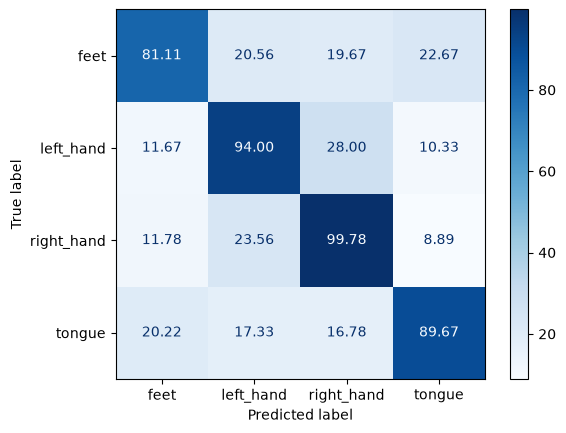



================ SCALE 0.2 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6267361111111112, 'auc': np.float64(0.8573937435699589), 'fmeasure': 0.6216771592278673}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6128472222222222, 'auc': np.float64(0.8703221450617283), 'fmeasure': 0.609056614441646}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.5972222222222222, 'auc': np.float64(0.8498223701131686), 'fmeasure': 0.5965113994599884}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6006944444444444, 'auc': np.float64(0.8551311728395062), 'fmeasure': 0.5984442840576484}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6232638888888888, 'auc': np.float64(0.8680394804526749), 'fmeasure': 0.6236704797041135}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6041666666666666, 'auc': np.float64(0.8526957947530865), 'fmeasure': 0.6032815593000131}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5885416666666666, 'auc': np.float64(0.8467198752572016), 'fmeasure': 0.587421009861171}

Fol

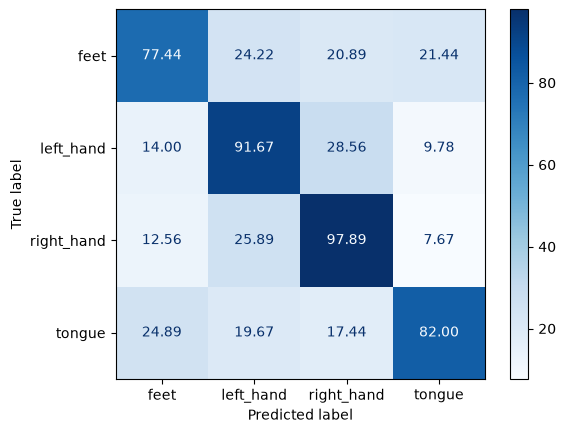



================ SCALE 0.3 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.609375, 'auc': np.float64(0.8469368891460906), 'fmeasure': 0.6073071278047828}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6180555555555556, 'auc': np.float64(0.8579644097222223), 'fmeasure': 0.6178799749217538}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.5729166666666666, 'auc': np.float64(0.8421465084876543), 'fmeasure': 0.5684395329187186}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6024305555555556, 'auc': np.float64(0.8458317258230453), 'fmeasure': 0.6006261064973605}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.858961066100823), 'fmeasure': 0.614587113457999}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.5868055555555556, 'auc': np.float64(0.8404505851337448), 'fmeasure': 0.5856559607392386}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5763888888888888, 'auc': np.float64(0.8355557163065844), 'fmeasure': 0.5746173223271686}

Fold 8/9

Fol

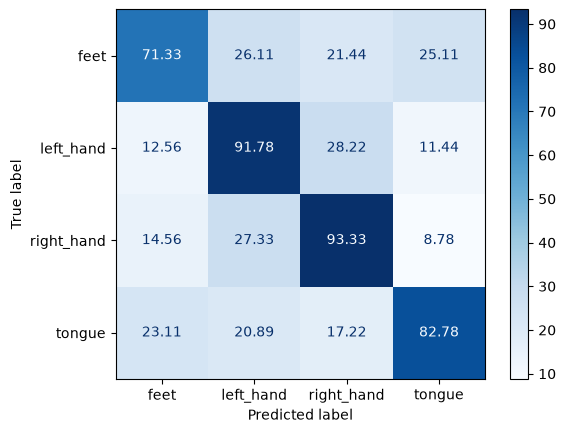



================ SCALE 0.4 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.5798611111111112, 'auc': np.float64(0.8169126157407408), 'fmeasure': 0.5772851957998968}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6059027777777778, 'auc': np.float64(0.8423474472736624), 'fmeasure': 0.6052328101297173}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.5677083333333334, 'auc': np.float64(0.8264250578703702), 'fmeasure': 0.5668531813223676}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.5798611111111112, 'auc': np.float64(0.8339723186728394), 'fmeasure': 0.5786898350500451}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6006944444444444, 'auc': np.float64(0.8431672775205761), 'fmeasure': 0.5986890313225306}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.5885416666666666, 'auc': np.float64(0.8292623135288065), 'fmeasure': 0.5876875405219844}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5416666666666666, 'auc': np.float64(0.8212287808641975), 'fmeasure': 0.539387882560491}

Fo

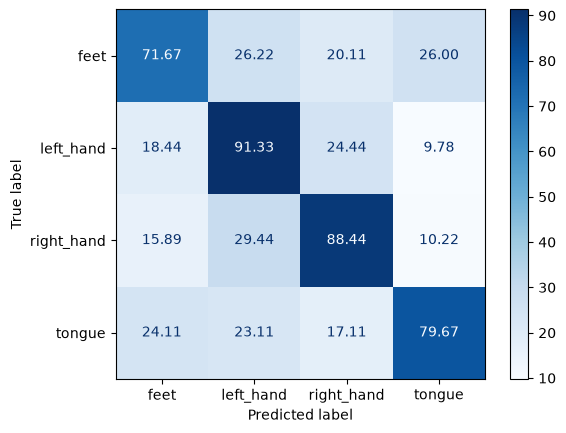

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}

for scale in [0.1, 0.2, 0.3, 0.4]:

    print(f"\n\n================ SCALE {scale} ================")


    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(logo.split(X_cv, y_cv, groups=subjects), start=1):

        X_tr = X_cv[train_idx].copy()
        X_va = X_cv[valid_idx].copy()

        y_tr = y_cv[train_idx]
        y_va = y_cv[valid_idx]

        X_tr = _add_noise(X_tr, scale)
        X_va = _add_noise(X_va, scale)

        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
            nb_classes=4,
            Chans=22,
            Samples=1001,
            kernLength=64,
            F1=32,
            D=4,
            F2=16,
            dropoutRate=0.4854763234903182,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0004102432506048275
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
        
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)
        #print("Confusion Matrix:")
        #print(cm)

    print(f"\n========== Scale {scale} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format=".2f"
    )

    plt.show()
    scale_results[scale] = avg_metrics
    scale_conf_mats[scale] = avg_cm

## train



================ SCALE 0.1 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6336805555555556, 'auc': np.float64(0.8665364583333334), 'fmeasure': 0.6334969422891684}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6440972222222222, 'auc': np.float64(0.8776925797325102), 'fmeasure': 0.6389196591820008}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.8575223443930041), 'fmeasure': 0.6150562616784523}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6215277777777778, 'auc': np.float64(0.8689035172325102), 'fmeasure': 0.619505991873186}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.65625, 'auc': np.float64(0.8758117926954733), 'fmeasure': 0.6541380273523131}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.8693013760288065), 'fmeasure': 0.6229055119377573}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6111111111111112, 'auc': np.float64(0.8505457497427984), 'fmeasure': 0.6111833775660774}

Fold 8/9

Fold 8 Final Val

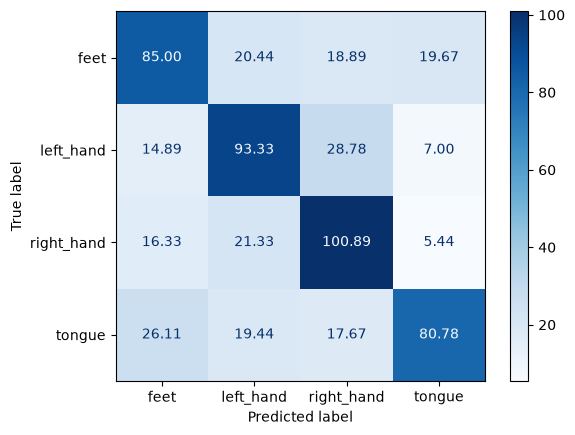



================ SCALE 0.2 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6215277777777778, 'auc': np.float64(0.8581492734053496), 'fmeasure': 0.6232115532104747}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6475694444444444, 'auc': np.float64(0.8829933449074074), 'fmeasure': 0.6440312178863705}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.609375, 'auc': np.float64(0.8486930941358025), 'fmeasure': 0.6075317474977601}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.65625, 'auc': np.float64(0.8690039866255145), 'fmeasure': 0.6545953718259765}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6197916666666666, 'auc': np.float64(0.8667816036522634), 'fmeasure': 0.6177471812950855}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6371527777777778, 'auc': np.float64(0.8661707497427984), 'fmeasure': 0.6347868645261341}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6041666666666666, 'auc': np.float64(0.8476924189814814), 'fmeasure': 0.6037716451656436}

Fold 8/9

Fold 8 Final

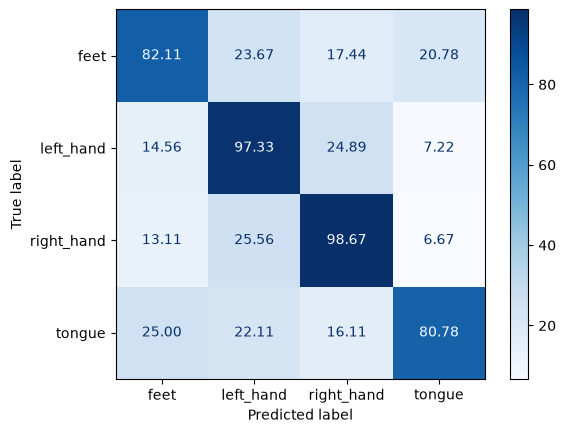



================ SCALE 0.3 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.625, 'auc': np.float64(0.8618264531893004), 'fmeasure': 0.6227325907540056}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6388888888888888, 'auc': np.float64(0.8641573431069958), 'fmeasure': 0.6370710714885032}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6111111111111112, 'auc': np.float64(0.8543555491255144), 'fmeasure': 0.6089045638903103}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6284722222222222, 'auc': np.float64(0.8638237847222222), 'fmeasure': 0.6289873259158201}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.866259162808642), 'fmeasure': 0.6140356814428053}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6059027777777778, 'auc': np.float64(0.855661651234568), 'fmeasure': 0.6048936830454269}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5989583333333334, 'auc': np.float64(0.8510159465020575), 'fmeasure': 0.5997665813807844}

Fold 8/9

Fold 8

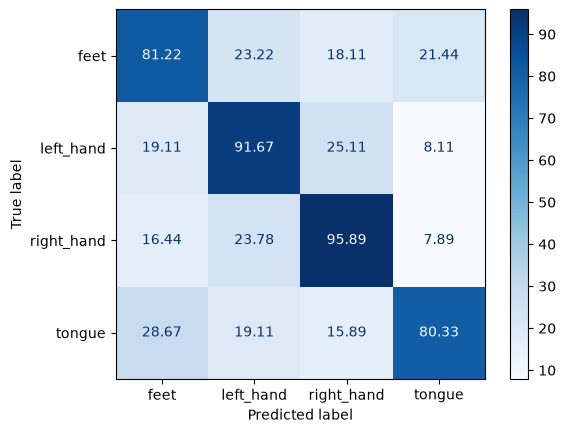



================ SCALE 0.4 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.5833333333333334, 'auc': np.float64(0.8441317836934158), 'fmeasure': 0.5797212015949098}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6180555555555556, 'auc': np.float64(0.8563046553497943), 'fmeasure': 0.6146969118086816}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.5920138888888888, 'auc': np.float64(0.8363152649176954), 'fmeasure': 0.5897232651630636}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6145833333333334, 'auc': np.float64(0.8499630272633745), 'fmeasure': 0.6120910456592241}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6024305555555556, 'auc': np.float64(0.8585511509773663), 'fmeasure': 0.6014445681447118}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.578125, 'auc': np.float64(0.8428055877057612), 'fmeasure': 0.5784980546698117}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.5642361111111112, 'auc': np.float64(0.8344706468621399), 'fmeasure': 0.5594294140017472}

Fold 8/9

F

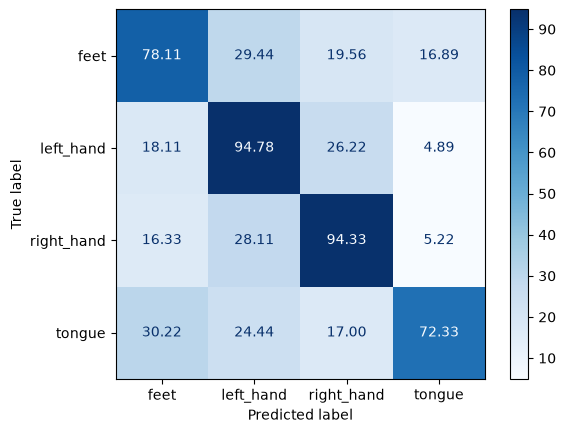

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}

for scale in [0.1, 0.2, 0.3, 0.4]:

    print(f"\n\n================ SCALE {scale} ================")


    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(logo.split(X_cv, y_cv, groups=subjects), start=1):

        X_tr = X_cv[train_idx].copy()
        X_va = X_cv[valid_idx].copy()

        y_tr = y_cv[train_idx]
        y_va = y_cv[valid_idx]

        X_tr = _add_noise(X_tr, scale)

        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
        nb_classes=4,
        Chans=22,
        Samples=1001,
        kernLength=250,
        F1=8,
        D=1,
        F2=16,
        dropoutRate=0.25550867989537085,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0026353430928847833, 
            weight_decay=1.4077242503865625e-06
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
        
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)
        #print("Confusion Matrix:")
        #print(cm)

    print(f"\n========== Scale {scale} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format=".2f"
    )

    plt.show()
    scale_results[scale] = avg_metrics
    scale_conf_mats[scale] = avg_cm

## test



================ SCALE 0.1 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.6527777777777778, 'auc': np.float64(0.8706999099794239), 'fmeasure': 0.6537552163562143}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6805555555555556, 'auc': np.float64(0.8892103909465021), 'fmeasure': 0.6789077278114871}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.609375, 'auc': np.float64(0.8572289737654321), 'fmeasure': 0.6080764373659031}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6197916666666666, 'auc': np.float64(0.8717005851337448), 'fmeasure': 0.6195092790379313}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6336805555555556, 'auc': np.float64(0.8810442386831275), 'fmeasure': 0.6294046801182851}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6388888888888888, 'auc': np.float64(0.8632651748971193), 'fmeasure': 0.6377943350348687}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6267361111111112, 'auc': np.float64(0.8628070344650206), 'fmeasure': 0.6271743815804773}

Fold 8/9

F

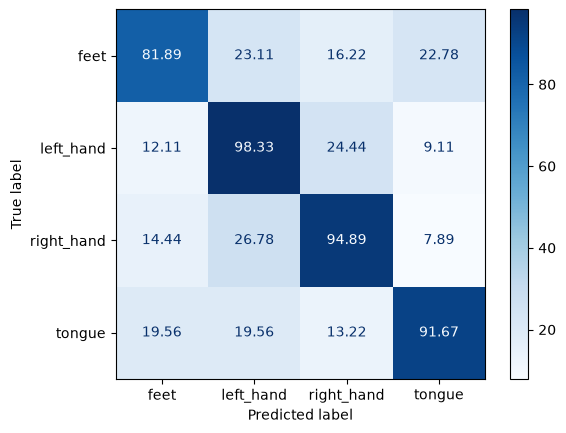



================ SCALE 0.2 ================

Fold 1/9

Fold 1 Final Validation -
{'acc': 0.5850694444444444, 'auc': np.float64(0.8464305234053499), 'fmeasure': 0.5744577718274}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6440972222222222, 'auc': np.float64(0.8809276941872429), 'fmeasure': 0.6411376407374005}

Fold 3/9

Fold 3 Final Validation -
{'acc': 0.6180555555555556, 'auc': np.float64(0.8537045074588477), 'fmeasure': 0.6176617256041546}

Fold 4/9

Fold 4 Final Validation -
{'acc': 0.6284722222222222, 'auc': np.float64(0.8547735018004116), 'fmeasure': 0.6288531362169951}

Fold 5/9

Fold 5 Final Validation -
{'acc': 0.6336805555555556, 'auc': np.float64(0.8686543531378601), 'fmeasure': 0.6339772502664871}

Fold 6/9

Fold 6 Final Validation -
{'acc': 0.6302083333333334, 'auc': np.float64(0.868847254372428), 'fmeasure': 0.6302499951289944}

Fold 7/9

Fold 7 Final Validation -
{'acc': 0.6076388888888888, 'auc': np.float64(0.8473829732510288), 'fmeasure': 0.6089417148693312}

Fold 

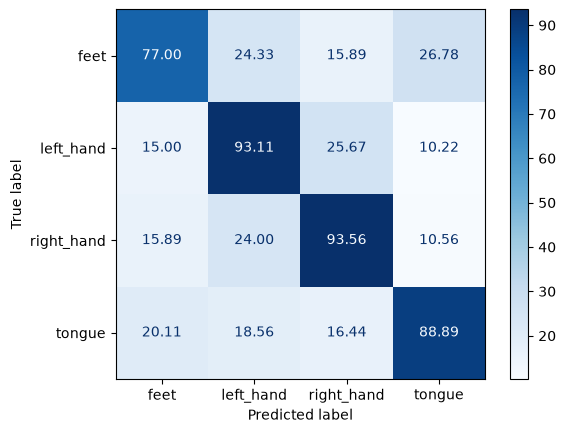



================ SCALE 0.3 ================

Fold 1/9
Early stopping at epoch 55

Fold 1 Final Validation -
{'acc': 0.5538194444444444, 'auc': np.float64(0.8301946694958849), 'fmeasure': 0.5524376139421797}

Fold 2/9

Fold 2 Final Validation -
{'acc': 0.6319444444444444, 'auc': np.float64(0.860054173096708), 'fmeasure': 0.6298288236630416}

Fold 3/9
Early stopping at epoch 44

Fold 3 Final Validation -
{'acc': 0.5277777777777778, 'auc': np.float64(0.8280606995884773), 'fmeasure': 0.521348119438371}

Fold 4/9
Early stopping at epoch 42

Fold 4 Final Validation -
{'acc': 0.5902777777777778, 'auc': np.float64(0.827051986882716), 'fmeasure': 0.5903650136932215}

Fold 5/9
Early stopping at epoch 52

Fold 5 Final Validation -
{'acc': 0.5677083333333334, 'auc': np.float64(0.8375691229423868), 'fmeasure': 0.5592442167159064}

Fold 6/9
Early stopping at epoch 49

Fold 6 Final Validation -
{'acc': 0.5868055555555556, 'auc': np.float64(0.8420741705246914), 'fmeasure': 0.5872260015117159}

Fold 

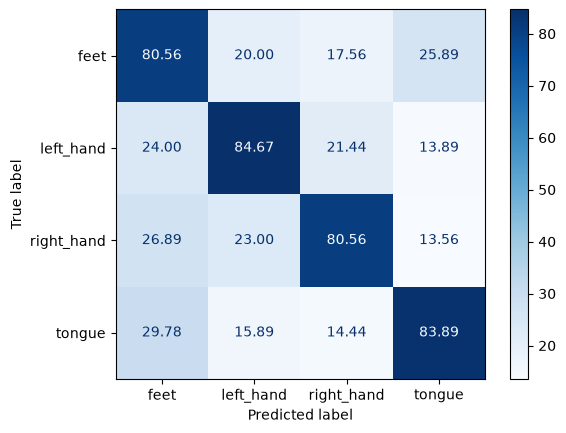



================ SCALE 0.4 ================

Fold 1/9
Early stopping at epoch 30

Fold 1 Final Validation -
{'acc': 0.5277777777777778, 'auc': np.float64(0.7969393004115227), 'fmeasure': 0.5216759869261018}

Fold 2/9
Early stopping at epoch 59

Fold 2 Final Validation -
{'acc': 0.6006944444444444, 'auc': np.float64(0.843163258744856), 'fmeasure': 0.6010521320471658}

Fold 3/9
Early stopping at epoch 28

Fold 3 Final Validation -
{'acc': 0.4878472222222222, 'auc': np.float64(0.7927637924382714), 'fmeasure': 0.4874476645079754}

Fold 4/9
Early stopping at epoch 36

Fold 4 Final Validation -
{'acc': 0.4618055555555556, 'auc': np.float64(0.8051255465534979), 'fmeasure': 0.4483387635025536}

Fold 5/9
Early stopping at epoch 51

Fold 5 Final Validation -
{'acc': 0.5572916666666666, 'auc': np.float64(0.841796875), 'fmeasure': 0.5545476860738013}

Fold 6/9
Early stopping at epoch 53

Fold 6 Final Validation -
{'acc': 0.5451388888888888, 'auc': np.float64(0.8359817065329217), 'fmeasure': 0.53

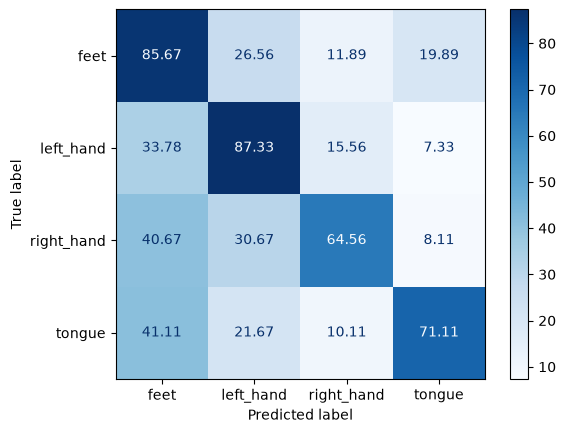

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

scale_results = {}
scale_conf_mats = {}

for scale in [0.1, 0.2, 0.3, 0.4]:

    print(f"\n\n================ SCALE {scale} ================")


    fold_results = []
    fold_conf_mats = []

    for fold, (train_idx, valid_idx) in enumerate(logo.split(X_cv, y_cv, groups=subjects), start=1):

        X_tr = X_cv[train_idx].copy()
        X_va = X_cv[valid_idx].copy()

        y_tr = y_cv[train_idx]
        y_va = y_cv[valid_idx]

        X_va = _add_noise(X_va, scale)

        train_ds = TensorDataset(
            torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.long)
        )

        valid_ds = TensorDataset(
            torch.tensor(X_va, dtype=torch.float32),
            torch.tensor(y_va, dtype=torch.long)
        )

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)

        net = EEGNetTorch(
            nb_classes=4,
            Chans=22,
            Samples=1001,
            kernLength=64,
            F1=32,
            D=4,
            F2=16,
            dropoutRate=0.4854763234903182,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0004102432506048275
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        epochs_without_improvement = 0

        for epoch in range(num_epochs):

            net.train()
            running_loss = 0.0
            n_seen = 0

            for inputs, labels in train_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad(set_to_none=True)
                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                n_seen += inputs.size(0)

            train_loss = running_loss / n_seen
            #print("Training Loss", train_loss)

            net.eval()
            val_loss = 0.0
            val_seen = 0

            with torch.no_grad():
                for inputs, labels in valid_loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * inputs.size(0)
                    val_seen += inputs.size(0)

            val_loss = val_loss / val_seen
            #print("Validation Loss", val_loss)

            #print("Train -", evaluate(net, X_tr, y_tr, params))
            #print("Validation -", evaluate(net, X_va, y_va, params))

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(net.state_dict())
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        metrics_raw = evaluate(net, X_va, y_va, params)

        if isinstance(metrics_raw, dict):
            metrics = metrics_raw
        else:
            metrics = dict(zip(params, metrics_raw))

        fold_results.append(metrics)

        # Confusion matrix for this fold
        net.eval()
        y_pred = []

        with torch.no_grad():
            X_tensor = torch.tensor(X_va, dtype=torch.float32).to(device)
            outputs = net(X_tensor)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_pred.extend(preds)

        cm = confusion_matrix(y_va, y_pred, labels=[0, 1, 2, 3], normalize="true")
        
        fold_conf_mats.append(cm)

        print(f"\nFold {fold} Final Validation -")
        print(metrics)
        #print("Confusion Matrix:")
        #print(cm)

    print(f"\n========== Scale {scale} Cross-Validation Results ==========")

    avg_metrics = {}

    for metric in params:
        values = [result[metric] for result in fold_results]
        avg_metrics[metric] = {
            "mean": np.mean(values),
            "std": np.std(values)
        }
        print(f"{metric}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    avg_cm = np.mean(fold_conf_mats, axis=0)

    
    print("\nAverage Confusion Matrix:")
    print(avg_cm)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=avg_cm,
        display_labels=le.classes_
    )

    disp.plot(
        cmap="Blues",
        values_format=".2f"
    )

    plt.show()
    scale_results[scale] = avg_metrics
    scale_conf_mats[scale] = avg_cm